# **SIT307 – Task 8.1D: Machine Learning Mini Project** 

# **Name:** Huynh Quang Vinh (Kent)

# **Student ID:** 224672479

# **Email:** s224672479@deakin.edu.au  

# **Unit:** SIT307 – Machine Learning 

## Part 1: Problem Definition and Data Collection

In this project, I will train a model to predict the sale price of houses in Sydney with 3 specific suburbs, which are Randwick, Parramatta and Blackstown. In this data, I just use House property.

After reviewing House properties of 3 suburbs in domain.com.au, I decide to create the dataset have total 112 properties with 35 properties in Randwick and 37, 40 properties in Parramatta and Blacktown, respectively.

The selected suburbs have difference price in housing market, where Randwick represent for the high housing price. Then, Parramatta represent for a major centre in West Sydney, which have a lower price than Randwick. Finally, Blacktown represent for further region, which often have a low price. 

Then, I will start to load the created dataset. 

In [1]:
import pandas as pd

df = pd.read_csv("sydney_housing_clean.csv")

df.head()

,listing_id,address,suburb,state,postcode,bedrooms,bathrooms,car_spaces,land_size_m2,latitude,longitude,sale_date,sale_method,sale_price,source_url
0,2020866983,2 Cooper Street,Blacktown,NSW,2148,3,1,1.0,556.0,-33.777637,150.90088,2026-07-17,by private treaty,999999,https://www.domain.com.au/2-cooper-street-blac...
1,2020820776,2 Sparkle Avenue,Blacktown,NSW,2148,3,2,3.0,556.0,-33.781544,150.89061,2026-07-17,by private treaty,1100000,https://www.domain.com.au/2-sparkle-avenue-bla...
2,2020934642,28 Cavendish Avenue,Blacktown,NSW,2148,3,2,3.0,556.0,-33.785645,150.91763,2026-07-17,by private treaty,1110000,https://www.domain.com.au/28-cavendish-avenue-...
3,2020872650,19 Valda Street,Blacktown,NSW,2148,3,1,2.0,550.0,-33.784580,150.90373,2026-07-18,by private treaty,925000,https://www.domain.com.au/19-valda-street-blac...
4,2021006298,202/3 Balmoral Street,Blacktown,NSW,2148,2,2,1.0,NaN,-33.769623,150.90376,2026-07-18,by private treaty,600000,https://www.domain.com.au/202-3-balmoral-stree...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   listing_id    112 non-null    int64  
 1   address       112 non-null    object 
 2   suburb        112 non-null    object 
 3   state         112 non-null    object 
 4   postcode      112 non-null    int64  
 5   bedrooms      112 non-null    int64  
 6   bathrooms     112 non-null    int64  
 7   car_spaces    105 non-null    float64
 8   land_size_m2  84 non-null     float64
 9   latitude      112 non-null    float64
 10  longitude     112 non-null    float64
 11  sale_date     112 non-null    object 
 12  sale_method   112 non-null    object 
 13  sale_price    112 non-null    int64  
 14  source_url    112 non-null    object 
dtypes: float64(4), int64(5), object(6)
memory usage: 13.3+ KB


In [3]:
df["suburb"].value_counts()

suburb
Blacktown     40
Parramatta    37
Randwick      35
Name: count, dtype: int64

Then, I will start to check missing and duplicate values of this dataset.

In [4]:
df.isnull().sum()

listing_id       0
address          0
suburb           0
state            0
postcode         0
bedrooms         0
bathrooms        0
car_spaces       7
land_size_m2    28
latitude         0
longitude        0
sale_date        0
sale_method      0
sale_price       0
source_url       0
dtype: int64

In [5]:
df.groupby("suburb")[["car_spaces", "land_size_m2"]].apply(lambda x: x.isnull().sum())

,car_spaces,land_size_m2
suburb,,
Blacktown,0,8
Parramatta,1,4
Randwick,6,16


In [6]:
df.duplicated().sum()

0

In [7]:
df.describe()

,listing_id,postcode,bedrooms,bathrooms,car_spaces,land_size_m2,latitude,longitude,sale_price
count,1.120000e+02,112.000000,112.000000,112.000000,105.000000,84.000000,112.000000,112.000000,1.120000e+02
mean,2.020630e+09,2112.098214,3.732143,1.982143,2.047619,594.654762,-33.831163,151.043097,2.206728e+06
std,4.028155e+05,54.928448,1.146732,0.890208,1.251007,571.714405,0.059069,0.142786,1.407827e+06
min,2.019467e+09,2031.000000,2.000000,1.000000,1.000000,132.000000,-33.926697,150.884750,6.000000e+05
25%,2.020420e+09,2031.000000,3.000000,1.000000,1.000000,448.250000,-33.906315,150.903597,1.187500e+06
50%,2.020750e+09,2148.000000,3.000000,2.000000,2.000000,556.000000,-33.811937,151.002500,1.676000e+06
75%,2.020945e+09,2150.000000,4.000000,3.000000,2.000000,600.000000,-33.780978,151.238635,2.925000e+06
max,2.021139e+09,2150.000000,9.000000,5.000000,8.000000,5478.000000,-33.749477,151.252640,8.005000e+06


## Part 2: Data Understanding and Feature Engineering

In this part, I will first evaluate the distribution of sale prices, which allows me to understand the overall price range, concentration of properties, and any possible extreme values in the dataset.

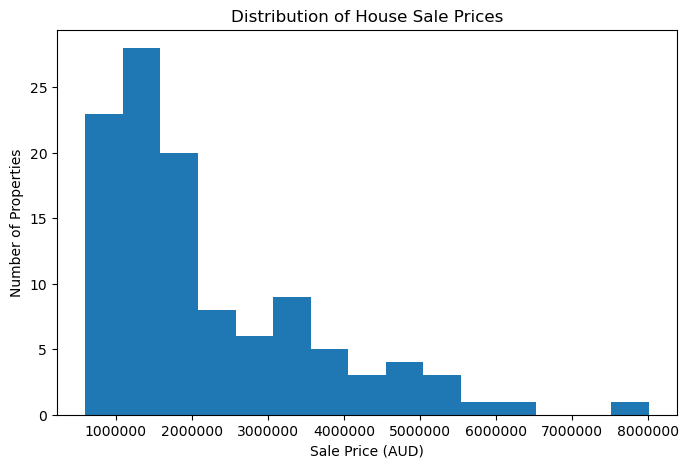

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["sale_price"], bins=15)

plt.xlabel("Sale Price (AUD)")
plt.ylabel("Number of Properties")
plt.title("Distribution of House Sale Prices")

plt.ticklabel_format(style="plain", axis="x")

plt.show()

According to the result, the distribution of sale prices is skewed, which most properties are concentratred in the lower price range. This range between 0.8 million to around 2 million. Meanwhile, the smaller number of properties have a significant higher sale prices. Then, the right tail is visible, which represent properties above 5 million dolars. This means that the presence of high price outlier should be handle carefully. 

After that, I will also visualize to acknowledge the difference prices between suburbs

<Figure size 800x500 with 0 Axes>

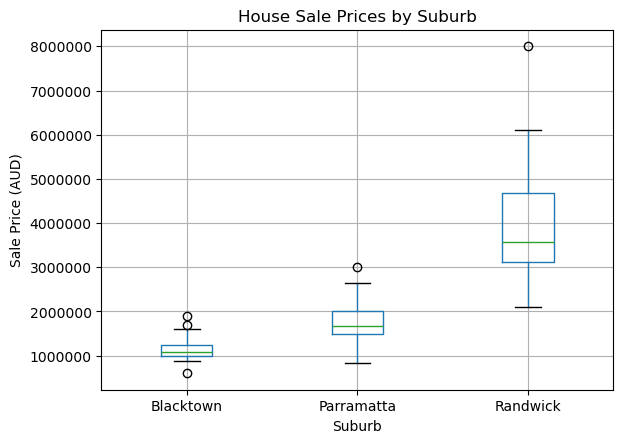

In [9]:
plt.figure(figsize=(8, 5))

df.boxplot(column="sale_price", by="suburb")

plt.xlabel("Suburb")
plt.ylabel("Sale Price (AUD)")
plt.title("House Sale Prices by Suburb")
plt.suptitle("")

plt.ticklabel_format(style="plain", axis="y")

plt.show()

According to the result, the Randwick suburb have a highest meadian price sales, while the Blacktown have a lowest one. Moreover, Randwick also demonstrates the wider price spread than another 2 suburbs. This also includes several potential outliers with a very high house price in Randwick at around 8 million dolar. Overall, this visualisation represent that 3 suburbs have a different housing market. 

Now, the sale dates will be converted to datetime format, which can help me to evaluate the housing price trends over time. 

In [10]:
df["sale_date"] = pd.to_datetime(df["sale_date"])

df["sale_date"].head()

0   2026-07-17
1   2026-07-17
2   2026-07-17
3   2026-07-18
4   2026-07-18
Name: sale_date, dtype: datetime64[ns]

Then, I will use the scatter plot to examine whether sale prices show any trend over time. 

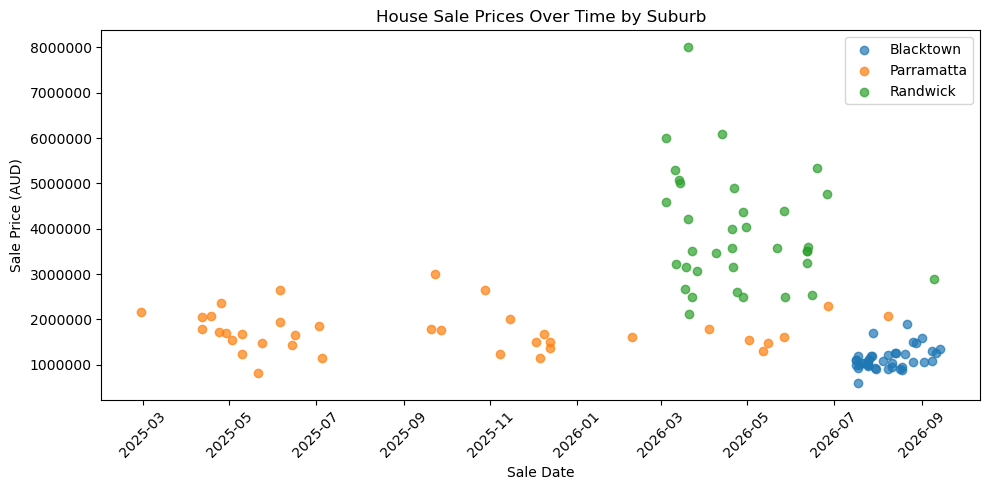

In [11]:
plt.figure(figsize=(10, 5))

for suburb in df["suburb"].unique():
    suburb_data = df[df["suburb"] == suburb]

    plt.scatter(
        suburb_data["sale_date"],
        suburb_data["sale_price"],
        label=suburb,
        alpha=0.7
    )

plt.xlabel("Sale Date")
plt.ylabel("Sale Price (AUD)")
plt.title("House Sale Prices Over Time by Suburb")
plt.ticklabel_format(style="plain", axis="y")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

According to the result, there is no any increasing or decreasing trend in sale prices over time. However, 3 suburbs do not cover all the same sale periods, which shows that Parramatta contains olders sales from 2025. Meanwhile, the most Randwick and Blacktown house is sale from 2026. 

After that, the potential outliers will be identified foe each suburb by using IQR method. This is more suitable than applying 1 threashold to all dataset because 3 suburbs have different range in housing prices.

In [12]:
outliers = []

for suburb in df["suburb"].unique():
    suburb_data = df[df["suburb"] == suburb]

    Q1 = suburb_data["sale_price"].quantile(0.25)
    Q3 = suburb_data["sale_price"].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    suburb_outliers = suburb_data[
        (suburb_data["sale_price"] < lower_bound) |
        (suburb_data["sale_price"] > upper_bound)
    ]

    outliers.append(suburb_outliers)

price_outliers = pd.concat(outliers)

price_outliers[
    ["address", "suburb", "bedrooms", "bathrooms",
     "car_spaces", "land_size_m2", "sale_price"]
].sort_values("sale_price")

,address,suburb,bedrooms,bathrooms,car_spaces,land_size_m2,sale_price
4,202/3 Balmoral Street,Blacktown,2,2,1.0,NaN,600000
16,53 - 53A Pelleas Street,Blacktown,7,4,2.0,584.0,1700000
30,13 Lancaster Street,Blacktown,7,4,6.0,739.0,1900000
59,14 ROSS STREET,Parramatta,3,3,8.0,437.0,3000000
86,5 Mort Street,Randwick,5,4,1.0,NaN,8005000


According to the result, 5 potential price outliers is indentified by using IQR method with each suburb. However, these observation will not be removed because several have property characteristics that may explain their unusual prices. For example, 2 high price houses in Backtown contain 7 bedrooms. Meanwhile, Randwick property sold for around 8 million dolar can contains some important characteristics but are not included in this dataset. 

According to the dataset, 3 expected important variables can be suburb, land size and number of bedrooms. Because suburbs represents for location of the house, which may have a strong effect because 3 selected suburbs representing for 3 different housing market. Then, about land size, the larger areas may increase property value because they provide more usable space. Finally, the number of bedrooms may represent for the overall size of the house, which may strong influent its sale price. 

Therefore, I will evaluate the relationship between these expected important variables with the target sale prices. The first one is land size. 

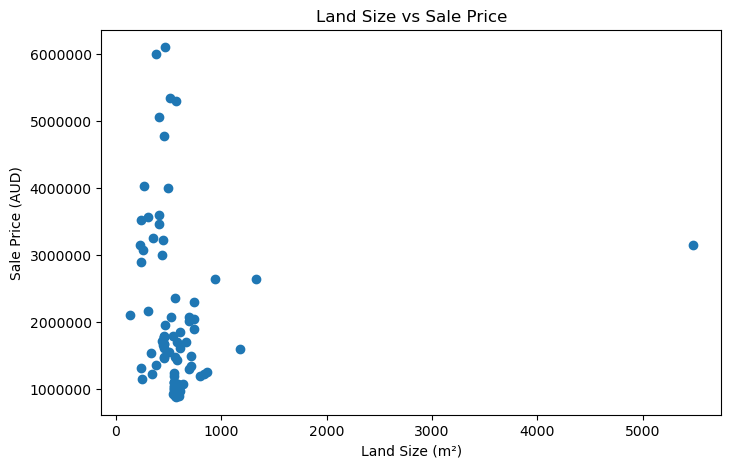

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(df["land_size_m2"], df["sale_price"])

plt.xlabel("Land Size (m²)")
plt.ylabel("Sale Price (AUD)")
plt.title("Land Size vs Sale Price")

plt.ticklabel_format(style="plain", axis="y")

plt.show()

According to the result, the visualisation does not demonstrate a clear positive relationship between land size and sale price. Most properties have land sizes below 1,000 m², while several high-priced houses still have relatively moderate land sizes. One property also has a very large land size but does not have the highest sale price. This suggests that land size alone may not explain house prices well.

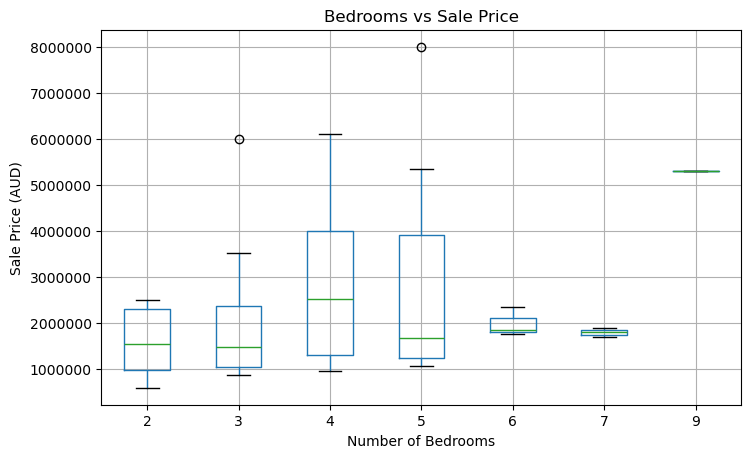

In [14]:
df.boxplot(column="sale_price", by="bedrooms", figsize=(8, 5))

plt.xlabel("Number of Bedrooms")
plt.ylabel("Sale Price (AUD)")
plt.title("Bedrooms vs Sale Price")
plt.suptitle("")

plt.ticklabel_format(style="plain", axis="y")

plt.show()

About the relationship between bedrooms and sale prices, the boxplot does not show a consistent increase in sale price as the number of bedrooms. For example, house with 4 bedrooms have a higher price than houses with 2 or 3 bedrooms. However, this pattern is not the same for house with 5 or more bedrooms. This means that the number of bedrooms may influent sale price but not only them. 

Now, I will start to handle some missing values in land size and car spaces founded at part 1. Therefore, I will first evaluate their distribution.

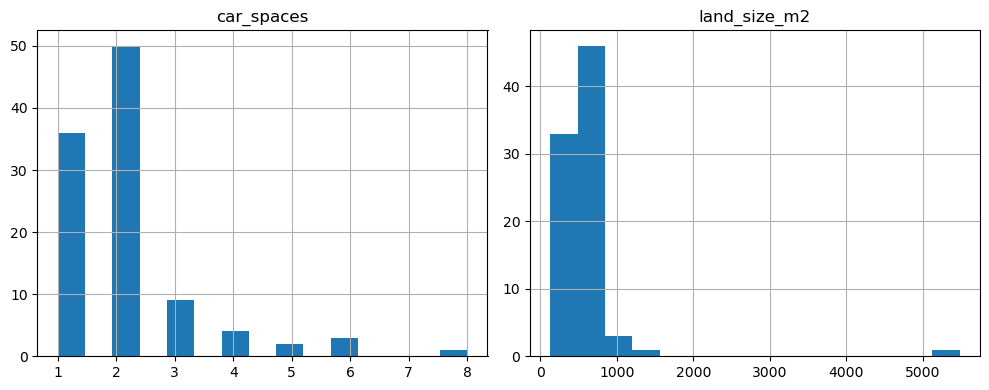

In [15]:
missing_numeric = [
    "car_spaces",
    "land_size_m2"
]

df[missing_numeric].hist(figsize=(10, 4), bins=15)

plt.tight_layout()
plt.show()

Both variables show prositively skewed distribution. This demonstrate that most houses have one or two car spaces, while only a small number of much higher values. Moreover, land size have more strongly skewed because most properties are below 1000m2. Therefore, the median is more suitable than the mean for handling these missing value. 

However, the missing values will not be filled at this stage. The median values will be calculated from the training data after the train-test split to avoid data leakage.

Then, I will start to do feature engineering step. I think the sale_data is the first handle feature, which is a useful information about the day house is sold. However, the raw datetime value connot be directly used by models. Therefore, the year and month will be extracted as new numerical features. 

In [16]:
df["sale_year"] = df["sale_date"].dt.year
df["sale_month"] = df["sale_date"].dt.month

df[["sale_date", "sale_year", "sale_month"]].head()

,sale_date,sale_year,sale_month
0,2026-07-17,2026,7
1,2026-07-17,2026,7
2,2026-07-17,2026,7
3,2026-07-18,2026,7
4,2026-07-18,2026,7


The distributions of the newly created time features are checked to confirm that they contain useful variation across the dataset.

In [17]:
print(df["sale_year"].value_counts().sort_index())
print()
print(df["sale_month"].value_counts().sort_index())

sale_year
2025    29
2026    83
Name: count, dtype: int64

sale_month
2      2
3     14
4     17
5     12
6     12
7     21
8     16
9     10
10     1
11     2
12     5
Name: count, dtype: int64


According to the result, the new time features contain enough variation to be useful. The dataset includes house sold in both 2025 and 2026 and the sale month range from february to december. Therefore, sale year and sale month will be retained as additional feature for modelling. 

## Part 3: Model Development and Evaluation

In this task, I will select 3 regression model, which are Linear Regression, Decision Tree Regressor and Random Forest Regressor. In this, Linear Regression is used as baseline model. It is easy to interpret and works well when the relationship between features and the target is nearly linear. However, it may have some difficult to capture more complex relationship. 
Then, the Decision Tree Regressor will be selected as the second model. According to GeeksforGeeks (2018), Decision Tree Regressor can be used to predict continuous values such as prices or scores using a tree-like structure. This can split the date into smaller group depending on rules from input features. Therefore, this model can capture non-linear relationship between features without assuming a linear relationship. However, a single decision tree can easily become too complex and overfit the training data.
Finally, the Random Forest Regressor will be selected as the third models. This is an ensemble learning method, which can combine multiple dicision trees to capture complex relationship while reducing the variance of a single tree (GeeksforGeeks, 2019).

Based on the EDA, I expected Random Forest Regressor to perform best because the housing contains non-linear relationships and interactions between property characteristics. Therefore, Random Forest may capture these pattern than Linear Regression. However, it will be more complex and less interpretable than Linear Regression.

At first, I will split the dataset into training and testing set within 80:20 ratio. 

Identification and reference columns such as listing_id, address and source_url are excluded from modelling. Then, state is constant for all properties, while postcode provides similar location information to suburb. Latitude and longitude are also excluded to keep the model and final application simple, with suburb used as the main location feature.

In [18]:
features = [
    "suburb",
    "bedrooms",
    "bathrooms",
    "car_spaces",
    "land_size_m2",
    "sale_method",
    "sale_year",
    "sale_month"
]

X = df[features]
y = df["sale_price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (112, 8)
y shape: (112,)


,suburb,bedrooms,bathrooms,car_spaces,land_size_m2,sale_method,sale_year,sale_month
0,Blacktown,3,1,1.0,556.0,by private treaty,2026,7
1,Blacktown,3,2,3.0,556.0,by private treaty,2026,7
2,Blacktown,3,2,3.0,556.0,by private treaty,2026,7
3,Blacktown,3,1,2.0,550.0,by private treaty,2026,7
4,Blacktown,2,2,1.0,NaN,by private treaty,2026,7


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (89, 8)
X_test shape: (23, 8)
y_train shape: (89,)
y_test shape: (23,)


According to the result, the dataset is now split into traing and testing set. Therefore, I will now fill missing values in land_size and car_spaces features with the median method. 

In [20]:
car_median = X_train["car_spaces"].median()
land_median = X_train["land_size_m2"].median()

print("Car spaces median:", car_median)
print("Land size median:", land_median)

Car spaces median: 2.0
Land size median: 556.0


In [21]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train["car_spaces"] = X_train["car_spaces"].fillna(car_median)
X_test["car_spaces"] = X_test["car_spaces"].fillna(car_median)

X_train["land_size_m2"] = X_train["land_size_m2"].fillna(land_median)
X_test["land_size_m2"] = X_test["land_size_m2"].fillna(land_median)

In [22]:
print("Training set missing values:")
print(X_train.isnull().sum())

print("\nTesting set missing values:")
print(X_test.isnull().sum())

Training set missing values:
suburb          0
bedrooms        0
bathrooms       0
car_spaces      0
land_size_m2    0
sale_method     0
sale_year       0
sale_month      0
dtype: int64

Testing set missing values:
suburb          0
bedrooms        0
bathrooms       0
car_spaces      0
land_size_m2    0
sale_method     0
sale_year       0
sale_month      0
dtype: int64


According to the result, the median values calculated from the training set are used to fill missing values in both the training and testing sets. This keeps the preprocessing consistent while preventing information from the test set from influencing the training process.

In [23]:
X_train.head(5)

,suburb,bedrooms,bathrooms,car_spaces,land_size_m2,sale_method,sale_year,sale_month
66,Parramatta,5,3,2.0,462.0,by private treaty,2025,12
90,Randwick,4,3,2.0,257.0,at auction,2026,3
62,Parramatta,3,2,2.0,343.0,by private treaty,2025,11
22,Blacktown,3,1,1.0,556.0,by private treaty,2026,8
85,Randwick,4,2,1.0,556.0,at auction,2026,3


Then, I will apply a suitable encoding method for non numerical feature in the dataset. 

In [24]:
print("Suburb values in training set:")
print(X_train["suburb"].unique())

print("\nSale method values in training set:")
print(X_train["sale_method"].unique())

print("\nSuburb values in testing set:")
print(X_test["suburb"].unique())

print("\nSale method values in testing set:")
print(X_test["sale_method"].unique())

Suburb values in training set:
['Parramatta' 'Randwick' 'Blacktown']

Sale method values in training set:
['by private treaty' 'at auction' 'prior to auction']

Suburb values in testing set:
['Parramatta' 'Blacktown' 'Randwick']

Sale method values in testing set:
['prior to auction' 'at auction' 'by private treaty']


According to the result, the hot-one encoding is suitable because these features contains not much unique values and not represent for any order. 

In [25]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["suburb", "sale_method"]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_encoded = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_encoded = encoder.transform(
    X_test[categorical_features]
)

encoded_feature_names = encoder.get_feature_names_out(categorical_features)

Then, the encoded categorical features are combined with the numerical features to create the final training and testing datasets. These datasets will be used consistently for all three regression models.

In [26]:
numeric_features = [
    "bedrooms",
    "bathrooms",
    "car_spaces",
    "land_size_m2",
    "sale_year",
    "sale_month"
]

X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_feature_names,
    index=X_train.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_feature_names,
    index=X_test.index
)

X_train_model = pd.concat(
    [X_train[numeric_features], X_train_encoded_df],
    axis=1
)

X_test_model = pd.concat(
    [X_test[numeric_features], X_test_encoded_df],
    axis=1
)

print("Final training shape:", X_train_model.shape)
print("Final testing shape:", X_test_model.shape)

X_train_model.head()

Final training shape: (89, 12)
Final testing shape: (23, 12)


,bedrooms,bathrooms,car_spaces,land_size_m2,sale_year,sale_month,suburb_Blacktown,suburb_Parramatta,suburb_Randwick,sale_method_at auction,sale_method_by private treaty,sale_method_prior to auction
66,5,3,2.0,462.0,2025,12,0.0,1.0,0.0,0.0,1.0,0.0
90,4,3,2.0,257.0,2026,3,0.0,0.0,1.0,1.0,0.0,0.0
62,3,2,2.0,343.0,2025,11,0.0,1.0,0.0,0.0,1.0,0.0
22,3,1,1.0,556.0,2026,8,1.0,0.0,0.0,0.0,1.0,0.0
85,4,2,1.0,556.0,2026,3,0.0,0.0,1.0,1.0,0.0,0.0


Now, I will start to train the Linear Regression model with 5 fold cross-validation will be applied to the training set. This cross validation is used because it can divide the training data into 5 folds instead of evaluating the model using only one validation split. According to GeeksforGeeks (2025), this can provide a more reliable estimate of model performance because the result is based on several different subsets of training data. 

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict

linear_model = LinearRegression()

linear_cv_predictions = cross_val_predict(
    linear_model,
    X_train_model,
    y_train,
    cv=5
)

linear_cv_predictions[:5]

array([2621753.95191836, 4319249.87284805, 1868298.01775429,
        859003.92479125, 4032843.13249953])

Then, I will use 3 evaluation metrics to examined the performance on this baseline model. 
I will apply the MAE, which is the absolute prediction error, having the formula:
$$
MAE = \frac{1}{n}\sum |y - \hat{y}|
$$
The second metrics is RMSE, which measures the average size by finding the square root of the average squared differences between predicted and actual values. This have a formula:
$$
RMSE = \sqrt{MSE}
$$
Finally, $R^2$ is used to measure the model and expalin how well a regression model fits the data. 

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_mae = mean_absolute_error(y_train, linear_cv_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_train, linear_cv_predictions))
linear_r2 = r2_score(y_train, linear_cv_predictions)

print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

MAE: 651690.77327289
RMSE: 1321379.0836961975
R²: 0.21261483781269463


According to the result, the Linear Regression model shows a weak predictive performance. The MAE represent an average prediction error of around 652,000 dollars. Meanwhile, the much higher RMSE suggests that some properties have very large prediction errors. The R² value of 0.213 shows that the model explains only about 21.3% of the variation in house sale prices. This suggests that the relationships in the housing dataset may not be well represented by a simple linear model.

To evaluate whether model is underfitting or overfitting, the Linear Regression model is trained on the full training set and evaluated on the same training data. The training metrics are then compared with the cross-validation results.

In [29]:
linear_model.fit(X_train_model, y_train)
linear_train_predictions = linear_model.predict(X_train_model)

linear_train_mae = mean_absolute_error(y_train, linear_train_predictions)
linear_train_rmse = np.sqrt(mean_squared_error(y_train,linear_train_predictions))
linear_train_r2 = r2_score(y_train, linear_train_predictions)

print("Training MAE:", linear_train_mae)
print("Training RMSE:", linear_train_rmse)
print("Training R²:", linear_train_r2)

Training MAE: 467560.395757535
Training RMSE: 698307.0587325701
Training R²: 0.7800999973456227


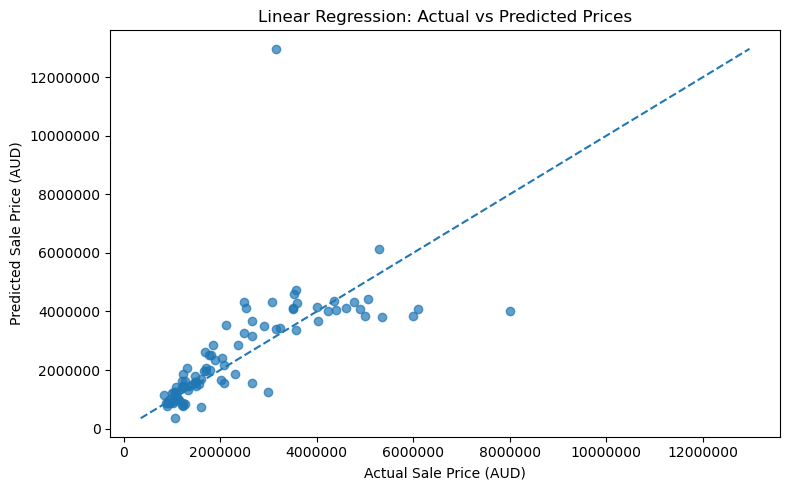

In [30]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_train,
    linear_cv_predictions,
    alpha=0.7
)

min_price = min(y_train.min(), linear_cv_predictions.min())
max_price = max(y_train.max(), linear_cv_predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Sale Price (AUD)")
plt.ylabel("Predicted Sale Price (AUD)")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()

The plot shows that Linear Regression performs reasonably for many lower and mid priced houses, where the predictions are close to the perfect prediction line. However, the prediction errors become much larger for several properties. For example, 1 property with an actual price around 3.3 million is predicted at nearly 13 million. Meanwhile, a house is sold for around 8 million was substantially underpredicted. These large errors explain the reason why RMSE is much higher than the MAE. Therefore, the results indicate that Linear Regression does not generalise well to unseen properties and have a sign of overfitting in this dataset.

Then, I will start to train the Dicision Tree Regressor and use the same evalutation metrics as Linear Regression. 

In [31]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_predict

tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_cv_predictions = cross_val_predict(
    tree_model,
    X_train_model,
    y_train,
    cv=5
)

tree_cv_predictions[:5]

array([1785000., 6100000., 1360000.,  960000., 4600000.])

In [32]:
tree_mae = mean_absolute_error(y_train, tree_cv_predictions)
tree_rmse = np.sqrt(mean_squared_error(y_train, tree_cv_predictions))
tree_r2 = r2_score(y_train, tree_cv_predictions)

print("MAE:", tree_mae)
print("RMSE:", tree_rmse)
print("R²:", tree_r2)

MAE: 635460.6741573034
RMSE: 1101926.2755982964
R²: 0.45243277092568757


After that, I will also examine whether the Decision Tree is overfitting by trainiing the model on the full training set and evaluated on the same training data. The training metrics are then compared with the 5 fold cross-validation results.

In [33]:
tree_model.fit(X_train_model, y_train)

tree_train_predictions = tree_model.predict(X_train_model)

tree_train_mae = mean_absolute_error(y_train, tree_train_predictions)
tree_train_rmse = np.sqrt(mean_squared_error(y_train, tree_train_predictions))
tree_train_r2 = r2_score(y_train, tree_train_predictions)

print("Training MAE:", tree_train_mae)
print("Training RMSE:", tree_train_rmse)
print("Training R²:", tree_train_r2)

Training MAE: 112.35955056179775
Training RMSE: 749.5316889958615
Training R²: 0.9999997466549821


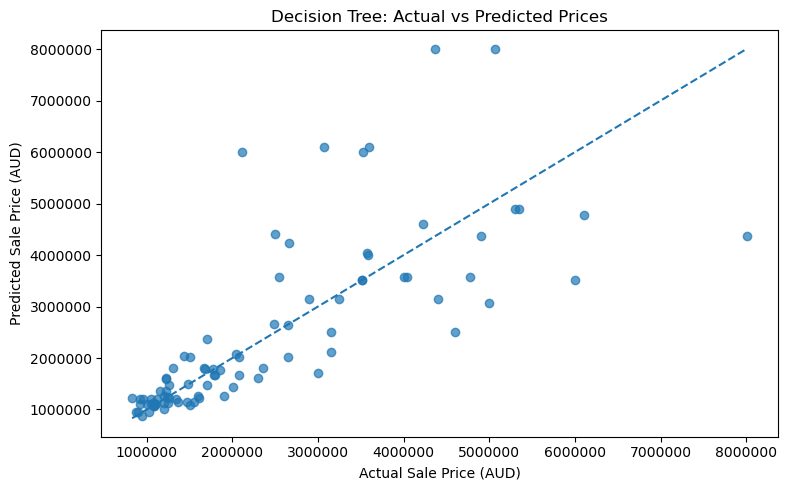

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_train,
    tree_cv_predictions,
    alpha=0.7
)

min_price = min(y_train.min(), tree_cv_predictions.min())
max_price = max(y_train.max(), tree_cv_predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Sale Price (AUD)")
plt.ylabel("Predicted Sale Price (AUD)")
plt.title("Decision Tree: Actual vs Predicted Prices")
plt.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()

According to the result, the Decision Tree performs better than Linear Regression, especially in lower price houses, where predictions are closer to the perfect prediction line. However, the errors become larger for high price properties. This is suitable with the cross validation $R^2$ and RMSE at around 1.1 million dollars. Although the model can capture non-linear relationship better than Linear Regression. Therefore, the training performance compared with weaker cross-validation shows that the Decision Tree strongly overfits the training data. 

Then, I will train the Random Forest Regressor, which is expected as the best model between 3 selected model. 

In [35]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_cv_predictions = cross_val_predict(
    rf_model,
    X_train_model,
    y_train,
    cv=5
)

rf_cv_predictions[:5]

array([1843165., 4398600., 1559030.,  988160., 4455650.])

I also use the same evaluation metrics. 

In [36]:
rf_mae = mean_absolute_error(y_train, rf_cv_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_train, rf_cv_predictions))
rf_r2 = r2_score(y_train, rf_cv_predictions)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

MAE: 484409.9063670412
RMSE: 792127.8785351063
R²: 0.7170413549840733


According to the result, the Random Forest Regressor achieve the best cross-validation performance among 3 selected models. It can produces the lowest MAE and RMSE, while its $R^2$ increase to around 0.7. This means that combing multiple decision tree allows the model to capture more complex and non-linear relationship in the housing data. 

Then, I will also check the training performance of Random Forest to acknowledge whether it is overfit. 

In [37]:
rf_model.fit(X_train_model, y_train)

rf_train_predictions = rf_model.predict(X_train_model)

rf_train_mae = mean_absolute_error(y_train, rf_train_predictions)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_predictions))
rf_train_r2 = r2_score(y_train, rf_train_predictions)

print("Training MAE:", rf_train_mae)
print("Training RMSE:", rf_train_rmse)
print("Training R²:", rf_train_r2)

Training MAE: 164513.33333333334
Training RMSE: 287640.7565775526
Training R²: 0.9626893156186569


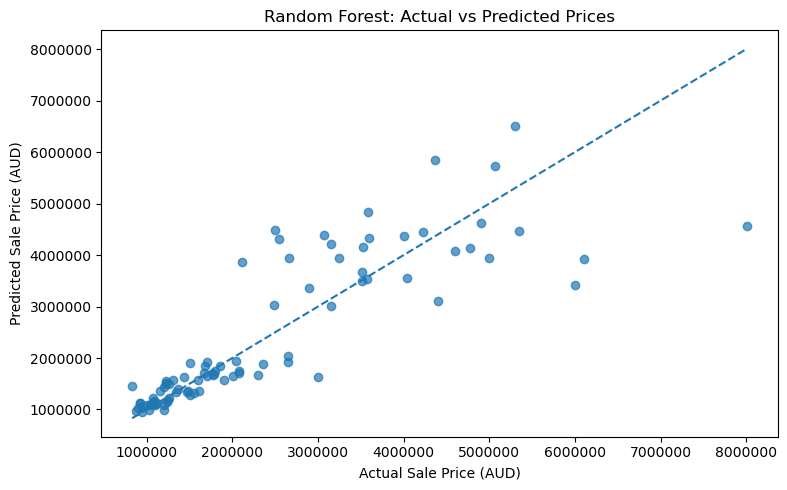

In [38]:
plt.figure(figsize=(8, 5))

plt.scatter(y_train, rf_cv_predictions, alpha=0.7)

min_price = min(y_train.min(), rf_cv_predictions.min())
max_price = max(y_train.max(), rf_cv_predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Sale Price (AUD)")
plt.ylabel("Predicted Sale Price (AUD)")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()

According to the result, the Random Forest also shows some signs of overfitting because its training performance is better than its cross-validation performance. The training $R^2$ is around 0.96, while cross-validation $R^2$ is around 0.17. However, the performance gap is much smaller than another 2 models. This means that averaging multiple decision trees can help Random Forest to reduce overfitting and generalise more effectively. 

Now, I will create the table of have a comparision between 3 selected models. 

In [39]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Train MAE": [
        linear_train_mae,
        tree_train_mae,
        rf_train_mae
    ],
    "CV MAE": [
        linear_mae,
        tree_mae,
        rf_mae
    ],
    "Train RMSE": [
        linear_train_rmse,
        tree_train_rmse,
        rf_train_rmse
    ],
    "CV RMSE": [
        linear_rmse,
        tree_rmse,
        rf_rmse
    ],
    "Train R²": [
        linear_train_r2,
        tree_train_r2,
        rf_train_r2
    ],
    "CV R²": [
        linear_r2,
        tree_r2,
        rf_r2
    ]
})

comparison.round(3)

,Model,Train MAE,CV MAE,Train RMSE,CV RMSE,Train R²,CV R²
0,Linear Regression,467560.396,651690.773,698307.059,1321379.084,0.780,0.213
1,Decision Tree,112.360,635460.674,749.532,1101926.276,1.000,0.452
2,Random Forest,164513.333,484409.906,287640.757,792127.879,0.963,0.717


According to the result, Random Forest can provide the best cross-validation performance among 3 selected models. It has the lowest CV MAE and RMSE and the highest CV $R^2$ at around 0.71. Meanwhile. Linear Regression has the weakest cross-validation performance, which demonstrates that a simple linear relationship is not sufficient to represent the housing data. Then, the Decision Tree performs better than Linear Regression, but it show the strongest overfitting. Finally, Random Forest also shows some overfitting sign, but its cross-validation performance can remain stronger than the other models. This means that combining multiple trees can improve generalisation compared with using a single Decision Tree. 

Therefore, I can acknowledge that Linear Regression is the most basic model in this task, but it cannot capture complex or non-linear relationship between features. This make it become the worst selected model in this dataset. Then, the Decision Tree can capture non-linear relationship and performs better than Linear Regression, but its almost perfect training compared with very low cross-validation performance demonstrate strong overfitting. Therefore, increasing model complexity can improve the ability to fit the training data, but the much complexity can reduce the generalisation. Finally, Random Forest provides the best balance between model complexity and generalisation. It can achieve the lowest cross-validation MAE and RMSE and the highest cross-validation $R^2$ between 3 selected models. Although it still shows some signs of overfitting, but the gap between training and cross-validation performance is very smaller than for the Decision Tree. As a result, the Random Forest is selected as the most suitable model for this predictive problem. 

## Part 4: Investigating Prediction Failures

In this part, the selected Random Forest model is used to predict the sale prices of held-out testing house. These properties is not used to train the model, which allows prediction failures to be investigated. 

In [40]:
rf_test_predictions = rf_model.predict(X_test_model)

rf_test_predictions[:5]

array([1656370., 1089145., 1053940., 1082150., 1798830.])

After that, the predicted prices are compared with the actual sale prices for each property in the testing set. The prediction error is calculated as the actual price - the predicted prices.

In [41]:
error_results = df.loc[X_test.index, [
    "address",
    "suburb",
    "bedrooms",
    "bathrooms",
    "car_spaces",
    "land_size_m2"
]].copy()

error_results["actual_price"] = y_test
error_results["predicted_price"] = rf_test_predictions

error_results["error"] = (
    error_results["actual_price"] -
    error_results["predicted_price"]
)

error_results["absolute_error"] = abs(
    error_results["error"]
)

error_results.head()

,address,suburb,bedrooms,bathrooms,car_spaces,land_size_m2,actual_price,predicted_price,error,absolute_error
40,84 Crimea Street,Parramatta,5,3,2.0,303.0,2170000,1656370.0,513630.0,513630.0
65,7 Trott Street,Parramatta,2,1,2.0,NaN,1150000,1089145.0,60855.0,60855.0
4,202/3 Balmoral Street,Blacktown,2,2,1.0,NaN,600000,1053940.0,-453940.0,453940.0
47,30 Wandsworth Street,Parramatta,2,1,2.0,332.0,1540000,1082150.0,457850.0,457850.0
42,6 Wandsworth Street,Parramatta,4,1,2.0,543.0,1800000,1798830.0,1170.0,1170.0


Then, I will get the top 5 largest error to investigate them. 

In [42]:
top_5_errors = error_results.sort_values(
    "absolute_error",
    ascending=False
).head(5)

top_5_errors

,address,suburb,bedrooms,bathrooms,car_spaces,land_size_m2,actual_price,predicted_price,error,absolute_error
91,9 Hay Street,Randwick,5,3,2.0,408.0,3460000,4864090.0,-1404090.0,1404090.0
80,1 Helena Street,Randwick,4,2,2.0,446.0,3220000,3973200.0,-753200.0,753200.0
40,84 Crimea Street,Parramatta,5,3,2.0,303.0,2170000,1656370.0,513630.0,513630.0
47,30 Wandsworth Street,Parramatta,2,1,2.0,332.0,1540000,1082150.0,457850.0,457850.0
4,202/3 Balmoral Street,Blacktown,2,2,1.0,NaN,600000,1053940.0,-453940.0,453940.0


In [43]:
top_5_errors = top_5_errors.copy()

top_5_errors["error_type"] = np.where(
    top_5_errors["error"] > 0,
    "Underprediction",
    "Overprediction"
)

top_5_errors["percentage_error"] = (
    top_5_errors["absolute_error"] /
    top_5_errors["actual_price"] * 100
)

top_5_errors["source_url"] = df.loc[
    top_5_errors.index,
    "source_url"
]

top_5_errors[
    [
        "address",
        "suburb",
        "actual_price",
        "predicted_price",
        "absolute_error",
        "percentage_error",
        "error_type",
        "source_url"
    ]
]

,address,suburb,actual_price,predicted_price,absolute_error,percentage_error,error_type,source_url
91,9 Hay Street,Randwick,3460000,4864090.0,1404090.0,40.580636,Overprediction,https://www.domain.com.au/9-hay-street-randwic...
80,1 Helena Street,Randwick,3220000,3973200.0,753200.0,23.391304,Overprediction,https://www.domain.com.au/1-helena-street-rand...
40,84 Crimea Street,Parramatta,2170000,1656370.0,513630.0,23.669585,Underprediction,https://www.domain.com.au/84-crimea-street-par...
47,30 Wandsworth Street,Parramatta,1540000,1082150.0,457850.0,29.730519,Underprediction,https://www.domain.com.au/30-wandsworth-street...
4,202/3 Balmoral Street,Blacktown,600000,1053940.0,453940.0,75.656667,Overprediction,https://www.domain.com.au/202-3-balmoral-stree...


I will first investigate the properties in 9 Hay Street, Randwick. I will access to the source url of this house to investigate whether any posible factores is not captured by the model.  

In [44]:
property_1 = df.loc[91]

property_1

listing_id                                             2020688165
address                                              9 Hay Street
suburb                                                   Randwick
state                                                         NSW
postcode                                                     2031
bedrooms                                                        5
bathrooms                                                       3
car_spaces                                                    2.0
land_size_m2                                                408.0
latitude                                                -33.92012
longitude                                               151.23679
sale_date                                     2026-04-09 00:00:00
sale_method                                      prior to auction
sale_price                                                3460000
source_url      https://www.domain.com.au/9-hay-street-randwic...
sale_year 

In this house, the Random Forest model predict around 4.86 million dollars, while the house is sold for 3.46 million dollars, which represent the overprediction of around 1.40 million. According to Domain.com , this property is a 5 bedrooms house in Randwick, where Domain report a median sold price of around 5.06 million dollars for 5 bedrooms houses. This can explain why the model provide a high prediction based on the suburb and number of bedrooms. However, several factors is not included in the model. For example, the Domain website declare that the property has an internal building area at around 190m2 and Domain also identifies flood risk for the property. These factors is not represented in the modelling features and may help explain why the actual sale price was lower than predicted. This example demonstrate that broad property characteristics may not fully capture the value of an individual house. 

The second property is the house in 1 Helena Street, Randwick. 

In [45]:
property_2 = df.loc[80]

property_2

listing_id                                             2020650435
address                                           1 Helena Street
suburb                                                   Randwick
state                                                         NSW
postcode                                                     2031
bedrooms                                                        4
bathrooms                                                       2
car_spaces                                                    2.0
land_size_m2                                                446.0
latitude                                               -33.925037
longitude                                               151.24008
sale_date                                     2026-03-12 00:00:00
sale_method                                      prior to auction
sale_price                                                3220000
source_url      https://www.domain.com.au/1-helena-street-rand...
sale_year 

The model predict around 3.97 million dollars, while the actual sale price is around 3.22 million, which means the overprediction. According to Domain website, which reports that the house has 4 bedrooms and an internal building area around 120m2. Domain also demonstrate that 4 bedrooms house in Randwick have a high median sale price, which may explain why model provide the overpredicted price. 
However, the internal building is not included as modelling features. Therefore, the model could not distinguish this house from 4 bedroom houses with similar broad characteristics. This means that bedrooms count alone may not correctly represent the actual size and value of the house. 

The third property is in 84 Crimea Stree, Parramatta. 

In [46]:
property_3 = df.loc[40]

property_3

listing_id                                             2019783125
address                                          84 Crimea Street
suburb                                                 Parramatta
state                                                         NSW
postcode                                                     2150
bedrooms                                                        5
bathrooms                                                       3
car_spaces                                                    2.0
land_size_m2                                                303.0
latitude                                               -33.822853
longitude                                                150.9915
sale_date                                     2025-02-28 00:00:00
sale_method                                      prior to auction
sale_price                                                2170000
source_url      https://www.domain.com.au/84-crimea-street-par...
sale_year 

In this property, the model predicts around 1.66 million dollars, while the house is sold at 2.17 million dollars, which represent the underprediction at around 514 thousand dollars. The structured dataset records 5 bedrooms, 2 car spaces and land size at 303m2. However, the original listing in realestate.com.au contains many additional characteristic that is not available in the model. For example, realesate declare that the property is architecturally design and includes and in-ground swimming pool, covered alfresco area, outdoor kitchen and premium interior features. Morever, it also indicates that the house is recently build and has a relatively large internal floor area. These characteristic may explain why the actual sale price was higher than model prediction. This case demonstrates that broad numerical features may underestimate houses with high construction quality and luxury features, which is not included in the collected dataset. 

The forth property is the house in 30 Wandsworth Street, Parramatta. 

In [47]:
property_4 = df.loc[47]

property_4

listing_id                                             2019917987
address                                      30 Wandsworth Street
suburb                                                 Parramatta
state                                                         NSW
postcode                                                     2150
bedrooms                                                        2
bathrooms                                                       1
car_spaces                                                    2.0
land_size_m2                                                332.0
latitude                                               -33.809376
longitude                                               151.01633
sale_date                                     2025-05-03 00:00:00
sale_method                                            at auction
sale_price                                                1540000
source_url      https://www.domain.com.au/30-wandsworth-street...
sale_year 

The model predict this house around 1.08 million dollars, while the actual price is 1.54 million dollars, which represent the inderprediction at around 458 thousand dollars. The original listing on realestate.com.au shows that the house is a 2 bedroom plus study cottage that had been extensively renovated. It also includes a renovated kitchen, high quality finishes, outdoor entertaining features and a convenient location close to parks, transport, schools and Parramatta CBD. These characteristic is not included in the modelling features. The model only use some information such as number of bedrooms, land size or suburb. This will treat this house as a typical 2 bedrooms house. Therefore, the renovation quality, addtional useable spaces and extract location can affect the sale price but is not included in the dataset. 

The last house in top 5 largest is the house in 202/3 Balmoral Street. 

In [48]:
property_5 = df.loc[4]

property_5

listing_id                                             2021006298
address                                     202/3 Balmoral Street
suburb                                                  Blacktown
state                                                         NSW
postcode                                                     2148
bedrooms                                                        2
bathrooms                                                       2
car_spaces                                                    1.0
land_size_m2                                                  NaN
latitude                                               -33.769623
longitude                                               150.90376
sale_date                                     2026-07-18 00:00:00
sale_method                                     by private treaty
sale_price                                                 600000
source_url      https://www.domain.com.au/202-3-balmoral-stree...
sale_year 

The model predict this house at around 1.05 million dollars, while the property sold sold for 600 thousand dollars, which resulting in an overprediction at around 454,000 dollars. This house the largest percentage error among 5 properties at around 75%. The proper has 2 bedroom and 1 car space, but its landsize and floor area are unavailable. According to Domain, market data for 2 bedrooms houses in Blacktown shows a higher typical price, which may explain why the model predict it a higher price than actual price. Moreover, the missing land size data may also have contributed to the error because the model used median training value during preprocessing step. In addition, the property also has an unusual address format compared with typical houses in dataset. Although the source still classifies it as a house, this may indicate that the property is less typical than the observations used to train the model. Therefore, the missing information and unusual house characteristic can produce a large prediction errors. 

According to 5 largest prediction errors, I can acknowledge that the model is limited by the information available in the collected dataset. Some important information that can affect the house price such as internal floor area, renovation quality, construction age, luxury features, ... is not included in the dataset. Moreover, the investigation above also demonstrates that missing values and unusual houses can reduce the prediction accuracy. For instance, the Blacktown house had missing land size information and characteristic that is quite different than most house in the dataset. Therefore, the model prediction should be interpreted cautiously for some houses that are highly renovated, newly built, unsually design or luxury architecture. 

## Part 5: Final Deployment and Reflection

The Random Forest is selected as the final model because it can achieve the best cross-validation performance in part 3. Therefore, before developing the web application, the trained model and the preprocessing information need to be saved. The application have to use the same preprocessing step that is used during the model development. Therefore, the Random Forest model, One-hot encoder, median values for missing data and feature information will be saved together. This can allow the web application to load and use the trained model without training it again each time the application is started. 

In [49]:
import joblib

model_bundle = {
    "model": rf_model,
    "encoder": encoder,
    "car_median": car_median,
    "land_median": land_median,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "encoded_feature_names": encoded_feature_names
}

According to joblib documentation, it is an open-source Python library designed for lightweight pipelining, parallel computing, and efficient serialization of large data. Therefore, the model bundle will be saved as a pkl file using joblib. This file will be loaded by the Streamlit application to make predictions for new property inputs. 

In [50]:
joblib.dump(
    model_bundle,
    "housing_model_bundle.pkl"
)

['housing_model_bundle.pkl']

Before building the web application, the saved model bundle is loaded again to confirm that the Random Forest model and preprocessing information were stored correctly. This simulates what the web application will do when it starts.

In [51]:
loaded_bundle = joblib.load("housing_model_bundle.pkl")

loaded_model = loaded_bundle["model"]
loaded_encoder = loaded_bundle["encoder"]
loaded_car_median = loaded_bundle["car_median"]
loaded_land_median = loaded_bundle["land_median"]

print("Car median:", loaded_car_median)
print("Land median:", loaded_land_median)
print("Model:", loaded_model)

Car median: 2.0
Land median: 556.0
Model: RandomForestRegressor(random_state=42)


In [52]:
loaded_predictions = loaded_model.predict(X_test_model)

loaded_predictions[:5]

array([1656370., 1089145., 1053940., 1082150., 1798830.])

In [53]:
rf_test_predictions[:5]

array([1656370., 1089145., 1053940., 1082150., 1798830.])

According to the result, the predictions produced by the loaded model are similar to the predictions from the original Random Forest model. This means that the model is saved and loaded successfully without changing its behaviour. The saved model can therefore be used in the web application for future predictions.

Then, the simple web application will be developed by using Streamlit. According to GeeksforGeeks (2020), Streamlit is an open-source Python library for building interactive web apps using only Python. Therefore, it can allow the machine learning model to be intergrated into a web interface by using Python without requiring a seperate front-end framework. 

## The remaining step of this part will be demonstrated in the report. 

After the app is built successfully, I will test using the property from the testing set. The same property information is entered into the Streamlit application and the predicted price will be compared with the prediction produced in the notebook. This means that the application applies the saved preprocessing and Random Forest model correctly. 

In [54]:
X_test.iloc[0]

suburb                Parramatta
bedrooms                       5
bathrooms                      3
car_spaces                   2.0
land_size_m2               303.0
sale_method     prior to auction
sale_year                   2025
sale_month                     2
Name: 40, dtype: object

In [55]:
print("Expected prediction:", rf_test_predictions[0])

Expected prediction: 1656370.0


## Acknowledgement
I used ChatGPT as a learning and technical support tool during this project. During the data collection stage, I manually saved the relevant property listing pages as HTML files, and ChatGPT assisted me in developing Python code to extract and structure the required property information into a CSV dataset. I reviewed the extracted data and checked the final dataset before using it for analysis.
In Part 5, I also used ChatGPT to help me understand new concepts that I had not previously used, including joblib, saving and loading trained machine learning models, and developing a simple web application using Streamlit. ChatGPT also provided guidance on the Python syntax required to implement these steps.
All suggestions and code provided by ChatGPT were reviewed, tested and modified where necessary. I understand the methods, code and concepts used in the final submission, and all final decisions, analysis and interpretations are my own.


## References
Domain. (n.d.-a). 9 Hay Street, Randwick NSW 2031. Retrieved September 17, 2026, from https://www.domain.com.au/property-profile/9-hay-street-randwick-nsw-2031

Domain. (n.d.-b). 1 Helena Street, Randwick NSW 2031. Retrieved September 17, 2026, from https://www.domain.com.au/property-profile/1-helena-street-randwick-nsw-2031

Domain. (n.d.-c). 202/3 Balmoral Street, Blacktown NSW 2148. Retrieved September 17, 2026, from https://www.domain.com.au/property-profile/202-3-balmoral-street-blacktown-ns

GeeksforGeeks. (2018, October 4). Decision tree regression using sklearn python. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/python-decision-tree-regression-using-sklearn/

GeeksforGeeks. (2019, June 14). Random forest regression in Python. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/random-forest-regression-in-python/

GeeksforGeeks. (2020, November 24). A beginners guide to streamlit. GeeksforGeeks. https://www.geeksforgeeks.org/python/a-beginners-guide-to-streamlit/

GeeksforGeeks. (2021, November 26). How to calculate mean absolute error in Python? GeeksforGeeks. https://www.geeksforgeeks.org/python/how-to-calculate-mean-absolute-error-in-python/

GeeksforGeeks. (2024, June 28). Calculating RMSE using scikitlearn. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/calculating-rmse-using-scikit-learn/

GeeksforGeeks. (2025, April 22). K fold cross validation in machine learning. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/k-fold-cross-validation-in-machine-learning/

Joblib: Running python functions as pipeline jobs — Joblib 1.3.2 documentation. (n.d.). Joblib.Readthedocs.Io. Retrieved September 17, 2026, from https://joblib.readthedocs.io/en/stable/

realestate.com.au. (n.d.-a). 84 Crimea Street, Parramatta NSW 2150. Retrieved September 17, 2026, from https://www.realestate.com.au/sold/property-house-nsw-parramatta-147205112

realestate.com.au. (n.d.-b). 30 Wandsworth Street, Parramatta NSW 2150. Retrieved September 17, 2026, from https://www.realestate.com.au/sold/property-house-nsw-parramatta-147731564